In [22]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------------------- -- 7.6/8.1 MB 36.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 35.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 32.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 35.8 MB/s  0:00:00

   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ---

Using device: cpu
Starting AG News Classification with LoRA Fine-tuning...
Class Labels: 1:World, 2:Sports, 3:Business, 4:Sci/Tech
Loading dataset and model...
Loading training dataset...
Loading test dataset...


Map: 100%|██████████| 500/500 [00:00<00:00, 12815.57 examples/s]


Training samples: 2000
Validation samples: 250
Test samples: 250
Initializing LoRA model...
Replaced 36 linear layers with LoRA versions
Frozen parameters: 100, Trainable parameters: 74
Trainable parameters: 334,852 / 66,697,732 (0.50%)

Starting LoRA training...
Epoch 1, Step 50, Loss: 0.7607
Epoch 1, Step 100, Loss: 0.1660
Epoch 1, Step 150, Loss: 0.5370
Epoch 1, Step 200, Loss: 0.0426
Epoch 1, Step 250, Loss: 0.2697
Epoch 1/2:
  Train Loss: 0.6201
  Val Loss: 0.3697
  Val Accuracy: 0.8920
--------------------------------------------------
Epoch 2, Step 50, Loss: 0.8903
Epoch 2, Step 100, Loss: 0.1802
Epoch 2, Step 150, Loss: 0.1331
Epoch 2, Step 200, Loss: 0.5385
Epoch 2, Step 250, Loss: 0.3256
Epoch 2/2:
  Train Loss: 0.3370
  Val Loss: 0.3556
  Val Accuracy: 0.9000
--------------------------------------------------

Final evaluation on test set...

FINAL RESULTS - LoRA Training
Test Loss: 0.3294
Test Accuracy: 0.9160

Per-class Performance:
  World      - Precision: 0.9016, Recall

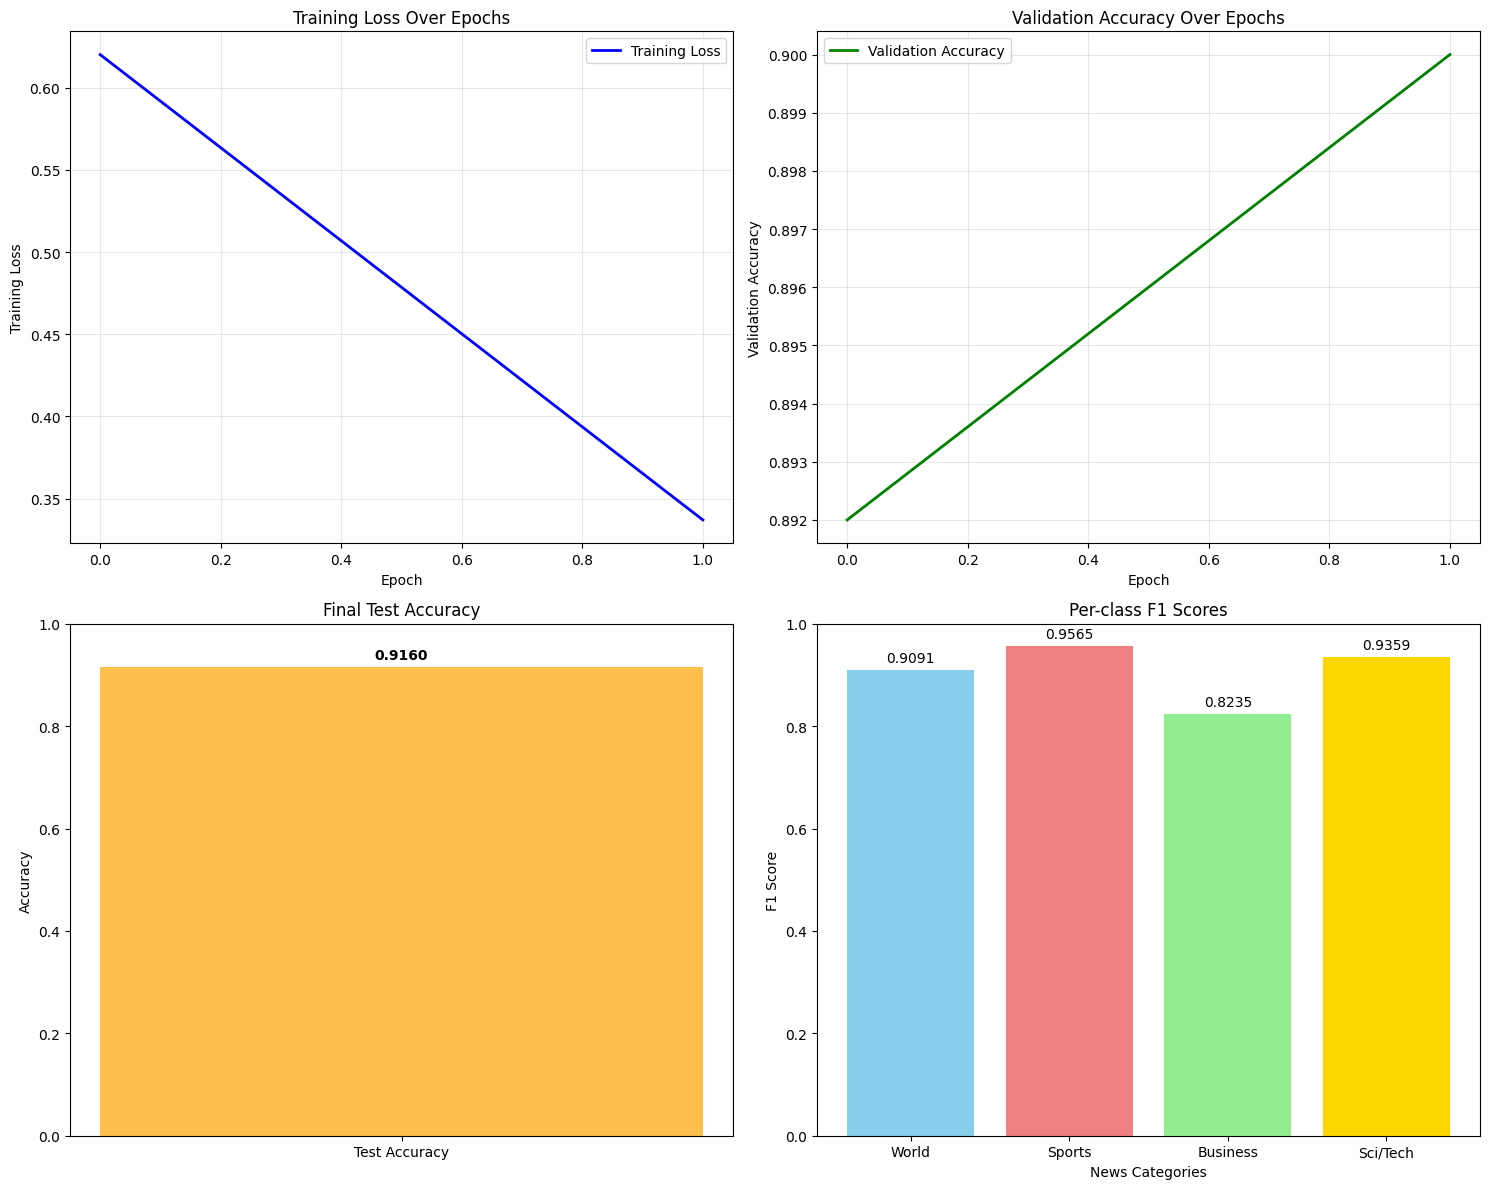


TRAINING SUMMARY - LoRA Fine-tuning
Model: DistilBERT-base-uncased with LoRA
Trainable parameters: 334,852
Total parameters: 66,697,732
Parameter efficiency: 0.50%
Final Test Accuracy: 0.9160
Final Test Loss: 0.3294

Results saved to lora_ag_news_summary_20251007_165714.json


In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer, AutoConfig
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import math
from typing import List, Optional
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from datetime import datetime
import json

# Check if CUDA is available and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# LoRA base layer class
class LoRALayer:
    def __init__(
        self, 
        r: int,                    # LoRA rank
        lora_alpha: int,           # Scaling factor
        lora_dropout: float,       # Dropout ratio
        merge_weights: bool,       # Flag for weight merging
    ):
        self.r = r
        self.lora_alpha = lora_alpha
        if lora_dropout > 0.:
            self.lora_dropout = nn.Dropout(p=lora_dropout)
        else:
            self.lora_dropout = lambda x: x
        self.merged = False
        self.merge_weights = merge_weights

# LoRA linear layer implementation
class Linear(nn.Linear, LoRALayer):
    def __init__(
        self, 
        in_features: int,
        out_features: int,
        r: int = 0,
        lora_alpha: int = 1,
        lora_dropout: float = 0.,
        fan_in_fan_out: bool = False,
        merge_weights: bool = True,
        **kwargs
    ):
        nn.Linear.__init__(self, in_features, out_features, **kwargs)
        LoRALayer.__init__(self, r=r, lora_alpha=lora_alpha, lora_dropout=lora_dropout,
                          merge_weights=merge_weights)
        self.fan_in_fan_out = fan_in_fan_out
        
        if r > 0:
            self.lora_A = nn.Parameter(self.weight.new_zeros((r, in_features)))
            self.lora_B = nn.Parameter(self.weight.new_zeros((out_features, r)))
            self.scaling = self.lora_alpha / self.r
            self.weight.requires_grad = False
            if self.bias is not None:
                self.bias.requires_grad = False
        
        self.reset_parameters()
        if fan_in_fan_out:
            self.weight.data = self.weight.data.transpose(0, 1)

    def reset_parameters(self):
        nn.Linear.reset_parameters(self)
        if hasattr(self, 'lora_A'):
            nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
            nn.init.zeros_(self.lora_B)

    def train(self, mode: bool = True):
        def T(w):
            return w.transpose(0, 1) if self.fan_in_fan_out else w
            
        nn.Linear.train(self, mode)
        if mode:
            if self.merge_weights and self.merged:
                if self.r > 0:
                    self.weight.data -= T(self.lora_B @ self.lora_A) * self.scaling
                self.merged = False
        else:
            if self.merge_weights and not self.merged:
                if self.r > 0:
                    self.weight.data += T(self.lora_B @ self.lora_A) * self.scaling
                self.merged = True

    def forward(self, x: torch.Tensor):
        def T(w):
            return w.transpose(0, 1) if self.fan_in_fan_out else w
            
        if self.r > 0 and not self.merged:
            result = F.linear(x, T(self.weight), bias=self.bias)
            result += (self.lora_dropout(x) @ self.lora_A.transpose(0, 1) @ self.lora_B.transpose(0, 1)) * self.scaling
            return result
        else:
            return F.linear(x, T(self.weight), bias=self.bias)

class LoRATransformerWrapper(nn.Module):
    def __init__(self, model_name="deepseek-ai/Janus-Pro-1B", use_lora=True, lora_r=4, 
                 lora_alpha=8, lora_dropout=0.1, num_classes=4):
        super().__init__()
        
        # Load pre-trained model and tokenizer
        self.config = AutoConfig.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        
        # Add padding token if not present
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        
        self.use_lora = use_lora
        self.num_classes = num_classes
        
        # Replace linear layers with LoRA versions
        if use_lora:
            self._replace_layers_with_lora(lora_r, lora_alpha, lora_dropout)
        
        # Classification head
        self.classifier = nn.Linear(self.config.hidden_size, num_classes)
        
        # Freeze base model initially (only LoRA and classifier trainable)
        self._freeze_base_model()
    
    def _replace_layers_with_lora(self, lora_r, lora_alpha, lora_dropout):
        """Replace linear layers in the transformer with LoRA versions"""
        lora_config = dict(r=lora_r, lora_alpha=lora_alpha, lora_dropout=lora_dropout)
        
        replaced_count = 0
        for module_name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                # Skip classification head and some key layers
                if 'classifier' in module_name or 'pooler' in module_name:
                    continue
                
                # Create LoRA linear layer
                lora_linear = Linear(
                    in_features=module.in_features,
                    out_features=module.out_features,
                    bias=module.bias is not None,
                    **lora_config
                )
                
                # Copy original weights
                lora_linear.weight.data = module.weight.data.clone()
                if module.bias is not None:
                    lora_linear.bias.data = module.bias.data.clone()
                
                # Replace the module
                parent = self._get_parent_module(module_name)
                child_name = module_name.split('.')[-1]
                setattr(parent, child_name, lora_linear)
                replaced_count += 1
        
        print(f"Replaced {replaced_count} linear layers with LoRA versions")
    
    def _get_parent_module(self, module_name):
        """Get parent module given full module name"""
        modules = module_name.split('.')
        parent = self.model
        for mod in modules[:-1]:
            parent = getattr(parent, mod)
        return parent
    
    def _freeze_base_model(self):
        """Freeze all parameters except LoRA and classifier"""
        frozen_count = 0
        trainable_count = 0
        
        for name, param in self.model.named_parameters():
            if 'lora' not in name:
                param.requires_grad = False
                frozen_count += 1
            else:
                param.requires_grad = True
                trainable_count += 1
        
        # Classifier should be trainable
        for param in self.classifier.parameters():
            param.requires_grad = True
            trainable_count += 1
        
        print(f"Frozen parameters: {frozen_count}, Trainable parameters: {trainable_count}")
    
    def forward(self, input_ids, attention_mask=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use mean pooling for sequence classification
        if attention_mask is not None:
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
            sum_embeddings = torch.sum(outputs.last_hidden_state * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            pooled_output = sum_embeddings / sum_mask
        else:
            pooled_output = outputs.last_hidden_state.mean(dim=1)
        
        logits = self.classifier(pooled_output)
        return logits

def prepare_dataset(tokenizer, split='train', num_samples=None):
    """Load and prepare AG News dataset with correct column names"""
    dataset = load_dataset("ag_news", split=split)
    
    if num_samples:
        dataset = dataset.select(range(num_samples))
    
    def tokenize_function(examples):
        return tokenizer(
            examples['text'], 
            padding='max_length', 
            truncation=True, 
            max_length=128,  # Reduced length for CPU efficiency
            return_tensors="pt"
        )
    
    tokenized_dataset = dataset.map(
        tokenize_function, 
        batched=True,
        remove_columns=['text']
    )
    tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
    tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    
    return tokenized_dataset

def evaluate_model(model, dataloader, criterion):
    """Evaluate model performance"""
    model.eval()
    all_predictions = []
    all_labels = []
    total_loss = 0
    total_samples = 0
    
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
            loss = criterion(outputs, batch['labels'])
            
            total_loss += loss.item() * batch['input_ids'].size(0)
            total_samples += batch['input_ids'].size(0)
            
            predictions = torch.argmax(outputs, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    
    avg_loss = total_loss / total_samples
    accuracy = accuracy_score(all_labels, all_predictions)
    
    return avg_loss, accuracy, all_predictions, all_labels

def train_lora_model():
    """Train and evaluate LoRA model on AG News"""
    torch.manual_seed(42)
    
    # Training parameters - reduced for CPU training
    num_epochs = 2
    batch_size = 8  # Smaller batch size for CPU
    train_samples = 2000  # Smaller subset for faster training
    val_samples = 500
    learning_rate = 2e-4
    
    print("Loading dataset and model...")
    
    # Use a smaller, more efficient model for CPU
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Load datasets
    print("Loading training dataset...")
    train_dataset = prepare_dataset(tokenizer, 'train', num_samples=train_samples)
    print("Loading test dataset...")
    test_dataset = prepare_dataset(tokenizer, 'test', num_samples=val_samples)
    
    from torch.utils.data import DataLoader, random_split
    
    # Split test dataset into validation and test
    val_size = len(test_dataset) // 2
    test_size = len(test_dataset) - val_size
    val_dataset, test_dataset = random_split(test_dataset, [val_size, test_size])
    
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    # Initialize LoRA model
    print("Initializing LoRA model...")
    model = LoRATransformerWrapper(
        model_name=model_name,
        use_lora=True,
        lora_r=4,  # Smaller rank for CPU
        lora_alpha=8,
        lora_dropout=0.1,
        num_classes=4
    )
    model = model.to(device)  # Use .to(device) instead of .cuda()
    
    # Print trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Trainable parameters: {trainable_params:,} / {total_params:,} '
          f'({trainable_params/total_params*100:.2f}%)')
    
    # Training setup
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], 
        lr=learning_rate,
        weight_decay=0.01
    )
    criterion = nn.CrossEntropyLoss()
    
    # Training history
    train_losses = []
    val_accuracies = []
    class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
    
    print("\nStarting LoRA training...")
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0
        train_samples = 0
        
        for step, batch in enumerate(train_dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}
            
            optimizer.zero_grad()
            outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
            loss = criterion(outputs, batch['labels'])
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item() * batch['input_ids'].size(0)
            train_samples += batch['input_ids'].size(0)
            
            if (step + 1) % 50 == 0:
                print(f'Epoch {epoch+1}, Step {step+1}, Loss: {loss.item():.4f}')
        
        avg_train_loss = epoch_train_loss / train_samples
        train_losses.append(avg_train_loss)
        
        # Validation phase
        val_loss, val_accuracy, _, _ = evaluate_model(model, val_dataloader, criterion)
        val_accuracies.append(val_accuracy)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {avg_train_loss:.4f}')
        print(f'  Val Loss: {val_loss:.4f}')
        print(f'  Val Accuracy: {val_accuracy:.4f}')
        print('-' * 50)
    
    # Final evaluation on test set
    print("\nFinal evaluation on test set...")
    test_loss, test_accuracy, test_predictions, test_labels = evaluate_model(
        model, test_dataloader, criterion
    )
    
    # Classification report
    report = classification_report(test_labels, test_predictions, 
                                 target_names=class_names, output_dict=True)
    
    print(f"\n{'='*60}")
    print("FINAL RESULTS - LoRA Training")
    print(f"{'='*60}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nPer-class Performance:")
    for i, class_name in enumerate(class_names):
        precision = report[class_name]['precision']
        recall = report[class_name]['recall']
        f1 = report[class_name]['f1-score']
        print(f"  {class_name:10} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    print(f"\nMacro Avg F1: {report['macro avg']['f1-score']:.4f}")
    print(f"Weighted Avg F1: {report['weighted avg']['f1-score']:.4f}")
    
    # Plot results
    plot_training_results(train_losses, val_accuracies, test_accuracy, class_names, report)
    
    return {
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'classification_report': report,
        'predictions': test_predictions,
        'labels': test_labels,
        'trainable_params': trainable_params,
        'total_params': total_params
    }

def plot_training_results(train_losses, val_accuracies, test_accuracy, class_names, report):
    """Plot training and evaluation results"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Training loss
    ax1.plot(train_losses, label='Training Loss', linewidth=2, color='blue')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Loss')
    ax1.set_title('Training Loss Over Epochs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Validation accuracy
    ax2.plot(val_accuracies, label='Validation Accuracy', linewidth=2, color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Accuracy')
    ax2.set_title('Validation Accuracy Over Epochs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Test accuracy
    ax3.bar(['Test Accuracy'], [test_accuracy], color='orange', alpha=0.7)
    ax3.set_ylabel('Accuracy')
    ax3.set_title('Final Test Accuracy')
    ax3.text(0, test_accuracy + 0.01, f'{test_accuracy:.4f}', 
             ha='center', va='bottom', fontweight='bold')
    ax3.set_ylim(0, 1.0)
    
    # Plot 4: Per-class F1 scores
    f1_scores = [report[class_name]['f1-score'] for class_name in class_names]
    bars = ax4.bar(class_names, f1_scores, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    ax4.set_xlabel('News Categories')
    ax4.set_ylabel('F1 Score')
    ax4.set_title('Per-class F1 Scores')
    ax4.set_ylim(0, 1.0)
    
    # Add value labels on bars
    for bar, f1 in zip(bars, f1_scores):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{f1:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(f'lora_ag_news_results_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_training_summary(results):
    """Print detailed training summary"""
    print(f"\n{'='*80}")
    print("TRAINING SUMMARY - LoRA Fine-tuning")
    print(f"{'='*80}")
    print(f"Model: DistilBERT-base-uncased with LoRA")
    print(f"Trainable parameters: {results['trainable_params']:,}")
    print(f"Total parameters: {results['total_params']:,}")
    print(f"Parameter efficiency: {results['trainable_params']/results['total_params']*100:.2f}%")
    print(f"Final Test Accuracy: {results['test_accuracy']:.4f}")
    print(f"Final Test Loss: {results['test_loss']:.4f}")
    
    # Save results to JSON
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_filename = f'lora_ag_news_summary_{timestamp}.json'
    
    serializable_results = {
        'train_losses': results['train_losses'],
        'val_accuracies': results['val_accuracies'],
        'test_accuracy': results['test_accuracy'],
        'test_loss': results['test_loss'],
        'classification_report': results['classification_report'],
        'trainable_params': results['trainable_params'],
        'total_params': results['total_params'],
        'parameter_efficiency': results['trainable_params']/results['total_params']*100
    }
    
    with open(results_filename, 'w') as f:
        json.dump(serializable_results, f, indent=2)
    
    print(f"\nResults saved to {results_filename}")

if __name__ == "__main__":
    print("Starting AG News Classification with LoRA Fine-tuning...")
    print("Class Labels: 1:World, 2:Sports, 3:Business, 4:Sci/Tech")
    
    # Run LoRA training
    results = train_lora_model()
    
    # Print summary
    print_training_summary(results)

In [28]:
print(torch.cuda.is_available())

False
